# Phase 4 — Logistics Analysis

Transport cost, delivery time, mode, region, and distance.

**Prerequisite:** `make etl` has been run and `DATABASE_URL` points at the populated warehouse.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from src.eda import data_access

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")


In [2]:
shipments = data_access.load_shipment_detail()
shipments.shape

(180519, 18)

## 1. Transport cost

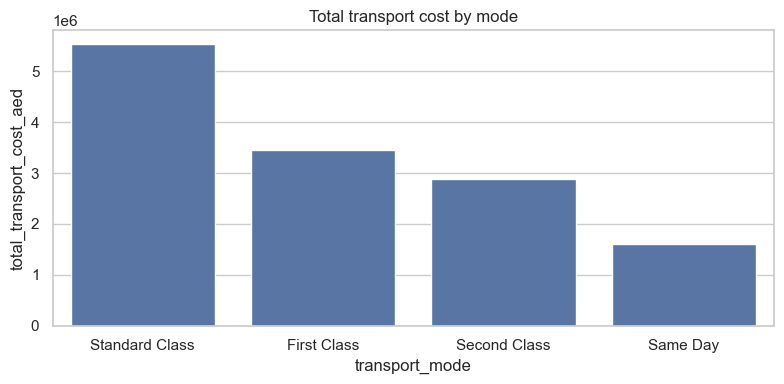

,transport_mode,shipment_count,total_transport_cost_aed,avg_transport_cost_aed
0,Standard Class,107752,"5,520,439.26",51.23
1,First Class,27814,"3,446,345.31",123.91
2,Second Class,35216,"2,881,993.45",81.84
3,Same Day,9737,"1,605,242.52",164.86


In [3]:
cost_by_mode = data_access.run_sql_file('05_logistics/01_transport_cost_by_mode.sql')
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=cost_by_mode, x='transport_mode', y='total_transport_cost_aed', ax=ax)
ax.set_title('Total transport cost by mode')
plt.tight_layout()
plt.show()
cost_by_mode

## 2. Delivery time

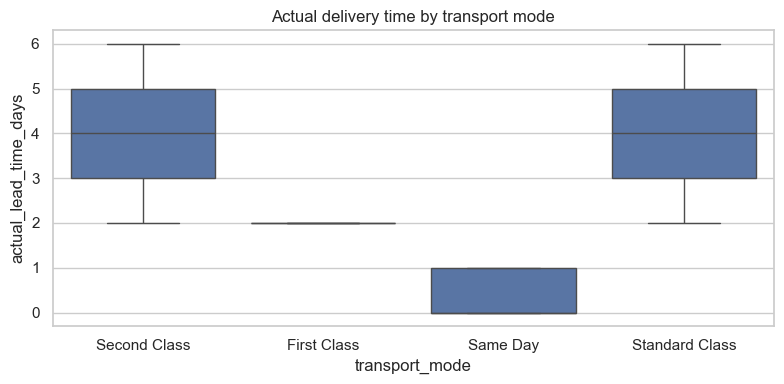

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=shipments, x='transport_mode', y='actual_lead_time_days', ax=ax)
ax.set_title('Actual delivery time by transport mode')
plt.tight_layout()
plt.show()

## 3. Mode

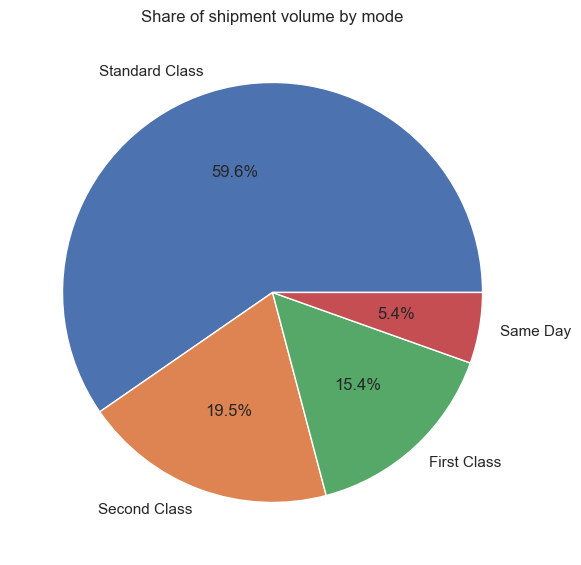

In [5]:
volume_by_mode = data_access.run_sql_file('05_logistics/02_shipment_volume_by_mode.sql')
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    volume_by_mode['total_units_shipped'], labels=volume_by_mode['transport_mode'],
    autopct='%1.1f%%',
)
ax.set_title('Share of shipment volume by mode')
plt.tight_layout()
plt.show()

## 4. Region

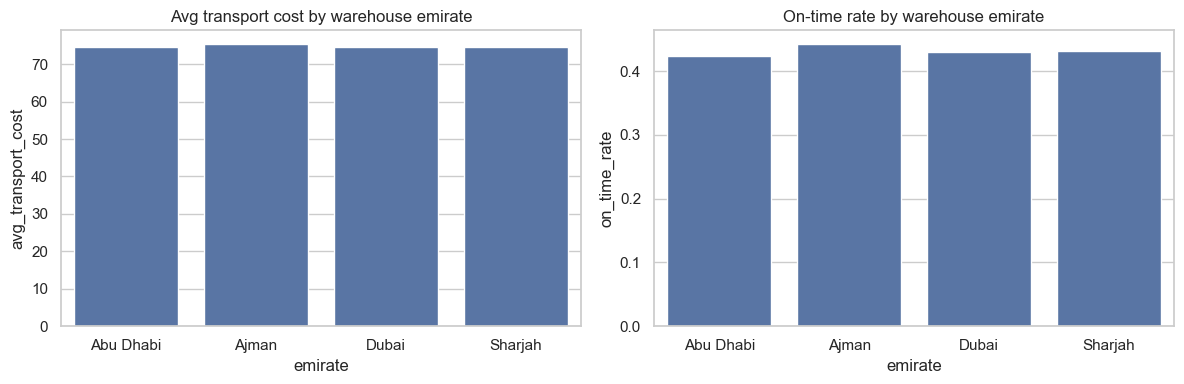

,emirate,avg_transport_cost,on_time_rate,shipment_count
0,Abu Dhabi,74.49,0.42,106372
1,Ajman,75.25,0.44,5548
2,Dubai,74.57,0.43,39459
3,Sharjah,74.49,0.43,29140


In [6]:
by_region = shipments.groupby('emirate').agg(
    avg_transport_cost=('transport_cost', 'mean'),
    on_time_rate=('on_time', 'mean'),
    shipment_count=('shipment_key', 'count'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=by_region, x='emirate', y='avg_transport_cost', ax=axes[0])
axes[0].set_title('Avg transport cost by warehouse emirate')
sns.barplot(data=by_region, x='emirate', y='on_time_rate', ax=axes[1])
axes[1].set_title('On-time rate by warehouse emirate')
plt.tight_layout()
plt.show()
by_region

## 5. Distance

`fact_shipments` doesn't store distance directly — it's back-derived here as `transport_cost / avg_cost_per_km` (both already in the warehouse). Since cost was itself computed as `distance x cost_per_km` at load time (`etl/synthesize/transport.py`), the relationship below is linear **by construction** within each transport option — a sanity check on the synthetic model, not an independent discovery.

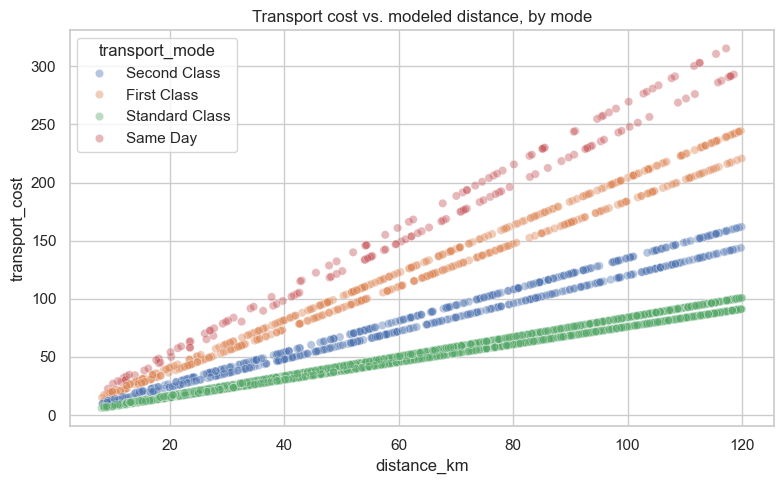

In [7]:
shipments['distance_km'] = shipments['transport_cost'] / shipments['avg_cost_per_km']

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=shipments.sample(min(3000, len(shipments)), random_state=42),
    x='distance_km', y='transport_cost', hue='transport_mode', alpha=0.4, ax=ax,
)
ax.set_title('Transport cost vs. modeled distance, by mode')
plt.tight_layout()
plt.show()